# ðŸ§  Notebook 05 â€” Evaluation: Stylized Facts
**Project:** Volatility-Regime-Conditioned DDPM for NIFTY50 Synthetic Returns  
**IIT Mandi Internship Â· Quant Ã— GenAI**

---
## What this notebook does
This is the core evaluation for the workshop paper. We rigorously compare:
1. **Real Returns** (Test set)
2. **Vanilla DDPM** (Unconditional synthetic returns)
3. **Conditional DDPM (Low Vol)** (Regime=0 synthetic returns)
4. **Conditional DDPM (High Vol)** (Regime=1 synthetic returns)

We evaluate against the classic **stylized facts** of financial time series (fat tails, volatility clustering, leverage effect) using both visual plots and rigorous statistical hypothesis testing.

## Cell 1 â€” Imports & Load Denormalized Data

In [1]:
import os
import json
import yaml
import numpy as np
import pandas as pd
import torch
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
colors = {'Real': '#2c3e50', 'Uncond': '#7f8c8d', 'Cond-Low': '#3498db', 'Cond-High': '#e74c3c'}

# Load Config
CONFIG_PATH = os.path.join('..', 'configs', 'config.yaml')
with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
WIN_DIR  = os.path.join(BASE_DIR, 'data', 'windows')
SAMP_DIR = os.path.join(BASE_DIR, 'outputs', 'samples')
FIG_DIR  = os.path.join(BASE_DIR, 'outputs', 'figures')
PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')

# Load Normalization Params
with open(os.path.join(PROC_DIR, 'norm_params.json'), 'r') as f:
    norm_params = json.load(f)
mu_ret, std_ret = norm_params['ret_mean'], norm_params['ret_std']

def denorm(x):
    return x * std_ret + mu_ret

# Load Real Test Data
real_data = torch.load(os.path.join(WIN_DIR, 'test_windows.pt'), weights_only=False)
real_windows = real_data['returns'].numpy()  # [N, 64]
real_returns = denorm(real_windows)

# Load Synthetic Data
uncond_windows = torch.load(os.path.join(SAMP_DIR, 'uncond_samples.pt'), weights_only=True).numpy()
cond_low_windows = torch.load(os.path.join(SAMP_DIR, 'cond_samples_low.pt'), weights_only=True).numpy()
cond_high_windows = torch.load(os.path.join(SAMP_DIR, 'cond_samples_high.pt'), weights_only=True).numpy()

uncond_returns = denorm(uncond_windows)
cond_low_returns = denorm(cond_low_windows)
cond_high_returns = denorm(cond_high_windows)

# Flatten for distribution-wide tests
real_flat = real_returns.flatten()
uncond_flat = uncond_returns.flatten()
cond_low_flat = cond_low_returns.flatten()
cond_high_flat = cond_high_returns.flatten()

print(f"Data Loaded and Denormalized:")
print(f"  Real returns       : {real_returns.shape}")
print(f"  Uncond DDPM        : {uncond_returns.shape}")
print(f"  Cond DDPM (Low)    : {cond_low_returns.shape}")
print(f"  Cond DDPM (High)   : {cond_high_returns.shape}")


Data Loaded and Denormalized:
  Real returns       : (791, 64)
  Uncond DDPM        : (500, 64)
  Cond DDPM (Low)    : (500, 64)
  Cond DDPM (High)   : (500, 64)


## Cell 2 â€” Stylized Facts Functions

In [2]:
def compute_moments(returns):
    return {
        'mean': np.mean(returns),
        'std': np.std(returns),
        'skew': stats.skew(returns),
        'kurtosis': stats.kurtosis(returns) # excess kurtosis
    }

def compute_hill_estimator(returns, tail_frac=0.05):
    """Estimate tail exponent alpha using the Hill estimator. Lower alpha = fatter tails."""
    # Consider only positive losses (negative returns) for the left tail
    losses = -returns[returns < 0]
    if len(losses) == 0: return np.nan
    losses = np.sort(losses)[::-1]
    k = int(len(losses) * tail_frac)
    if k < 2: return np.nan
    
    top_k = losses[:k]
    threshold = losses[k]
    hill_est = np.mean(np.log(top_k / threshold))
    return 1.0 / hill_est if hill_est > 0 else np.nan

def compute_acf(returns, nlags):
    # Using sm.tsa.acf
    # Returns an array of autocorrelations. We skip lag 0 (which is always 1)
    acf_vals = sm.tsa.acf(returns, nlags=nlags, fft=True)
    return acf_vals[1:] 

def compute_leverage(returns, max_lag):
    """Correlation between past returns and future absolute returns."""
    lev = []
    for lag in range(1, max_lag + 1):
        corr = np.corrcoef(returns[:-lag], np.abs(returns[lag:]))[0, 1]
        lev.append(corr)
    return np.array(lev)

def compute_max_drawdown(windows):
    """Compute average max drawdown across all generated 64-day paths."""
    mdds = []
    for path in windows:
        cum_ret = np.cumsum(path)
        peak = np.maximum.accumulate(cum_ret)
        drawdown = peak - cum_ret
        mdds.append(np.max(drawdown))
    return np.mean(mdds)


## Cell 3 â€” Statistical Tests Functions

In [3]:
def run_statistical_tests(synthetic_flat, real_flat, lags=5):
    results = {}
    
    # 1. Kolmogorov-Smirnov (KS) Test for distribution match
    ks_stat, ks_pval = stats.ks_2samp(synthetic_flat, real_flat)
    results['KS_stat'] = ks_stat
    results['KS_pval'] = ks_pval
    
    # 2. Jarque-Bera (Normality test) - should strongly reject
    jb_stat, jb_pval = stats.jarque_bera(synthetic_flat)
    results['JB_pval'] = jb_pval
    
    # 3. Ljung-Box Test (Autocorrelation in returns)
    lb_df = acorr_ljungbox(synthetic_flat, lags=[lags], return_df=True)
    results[f'LjungBox_pval_lag{lags}'] = lb_df['lb_pvalue'].iloc[0]
    
    # 4. ARCH-LM Test (Volatility clustering)
    # We test on the first 5000 points to keep computation reasonable
    sample_size = min(5000, len(synthetic_flat))
    arch_stat, arch_pval, _, _ = het_arch(synthetic_flat[:sample_size], nlags=lags)
    results[f'ARCH_LM_pval_lag{lags}'] = arch_pval
    
    return results


## Cell 4 & 5 â€” Compute Metrics and Build Table 1

In [4]:
datasets = {
    'Real': real_flat,
    'Uncond DDPM': uncond_flat,
    'Cond DDPM (Low Vol)': cond_low_flat,
    'Cond DDPM (High Vol)': cond_high_flat
}

window_datasets = {
    'Real': real_returns,
    'Uncond DDPM': uncond_returns,
    'Cond DDPM (Low Vol)': cond_low_returns,
    'Cond DDPM (High Vol)': cond_high_returns
}

metrics = []

for name, data in datasets.items():
    # Basic Moments
    moms = compute_moments(data)
    
    # Tail Index
    hill = compute_hill_estimator(data)
    
    # ACF (lag 1 and lag 5)
    acf_ret = compute_acf(data, nlags=5)
    acf_abs = compute_acf(np.abs(data), nlags=5)
    
    # Leverage (lag 1)
    lev = compute_leverage(data, max_lag=1)[0]
    
    # Max Drawdown (computed on paths)
    mdd = compute_max_drawdown(window_datasets[name])
    
    row = {
        'Model': name,
        'Mean (x10^-4)': moms['mean'] * 1e4,
        'Std Dev': moms['std'],
        'Skewness': moms['skew'],
        'Excess Kurtosis': moms['kurtosis'],
        'Tail Index (Hill)': hill,
        'ACF |r| (lag 1)': acf_abs[0],
        'ACF |r| (lag 5)': acf_abs[4],
        'Leverage Corr (lag 1)': lev,
        'Avg Max Drawdown': mdd
    }
    
    # Stat tests (Compare synthetic to real)
    if name != 'Real':
        tests = run_statistical_tests(data, real_flat, lags=5)
        row['KS Stat (vs Real)'] = tests['KS_stat']
        row['KS p-val'] = tests['KS_pval']
        row['Ljung-Box p-val'] = tests['LjungBox_pval_lag5']
        row['ARCH-LM p-val'] = tests['ARCH_LM_pval_lag5']
    else:
        # Real vs Real doesn't make sense for KS
        tests = run_statistical_tests(data, real_flat, lags=5) # For JB, LB, ARCH
        row['KS Stat (vs Real)'] = 0.0
        row['KS p-val'] = 1.0
        row['Ljung-Box p-val'] = tests['LjungBox_pval_lag5']
        row['ARCH-LM p-val'] = tests['ARCH_LM_pval_lag5']
        
    metrics.append(row)

df_results = pd.DataFrame(metrics).set_index('Model')
df_results = df_results.round(4)
display(df_results)

# Save to CSV for the paper
df_results.to_csv(os.path.join(PROC_DIR, 'table1_stylized_facts.csv'))
print("Saved Table 1 to data/processed/table1_stylized_facts.csv")


,Mean (x10^-4),Std Dev,Skewness,Excess Kurtosis,Tail Index (Hill),ACF |r| (lag 1),ACF |r| (lag 5),Leverage Corr (lag 1),Avg Max Drawdown,KS Stat (vs Real),KS p-val,Ljung-Box p-val,ARCH-LM p-val
Model,,,,,,,,,,,,,
Real,3.7469,0.0081,-0.4682,5.984800,2.8597,0.2462,0.0356,-0.0942,0.0618,0.0000,1.0,0.0,0.0
Uncond DDPM,5.7873,0.0109,0.2274,32.798599,2.5647,0.3035,0.2879,-0.0581,0.0738,0.0465,0.0,0.0,0.0
Cond DDPM (Low Vol),3.9433,0.0080,-2.6793,48.200199,2.5896,0.2550,0.2350,-0.0788,0.0586,0.0412,0.0,0.0,0.0
Cond DDPM (High Vol),0.4556,0.0225,-0.1248,10.401300,2.7772,0.2656,0.2748,-0.0402,0.1895,0.1883,0.0,0.0,0.0


Saved Table 1 to data/processed/table1_stylized_facts.csv


## Cell 6 â€” Publication Figure: Return Distributions

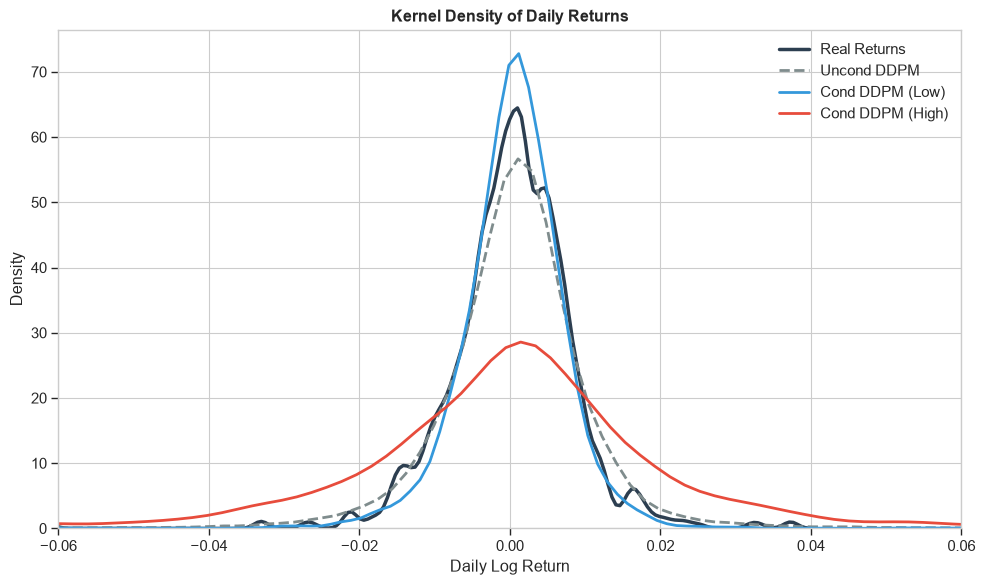

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(real_flat, label='Real Returns', color=colors['Real'], linewidth=2.5, ax=ax)
sns.kdeplot(uncond_flat, label='Uncond DDPM', color=colors['Uncond'], linewidth=2, linestyle='--', ax=ax)
sns.kdeplot(cond_low_flat, label='Cond DDPM (Low)', color=colors['Cond-Low'], linewidth=2, ax=ax)
sns.kdeplot(cond_high_flat, label='Cond DDPM (High)', color=colors['Cond-High'], linewidth=2, ax=ax)

ax.set_xlim(-0.06, 0.06)
ax.set_title('Kernel Density of Daily Returns', fontweight='bold')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb05_return_distributions.png'), dpi=300)
plt.savefig(os.path.join(FIG_DIR, 'nb05_return_distributions.pdf'))
plt.show()


## Cell 7 â€” Publication Figure: QQ Plot vs Normal

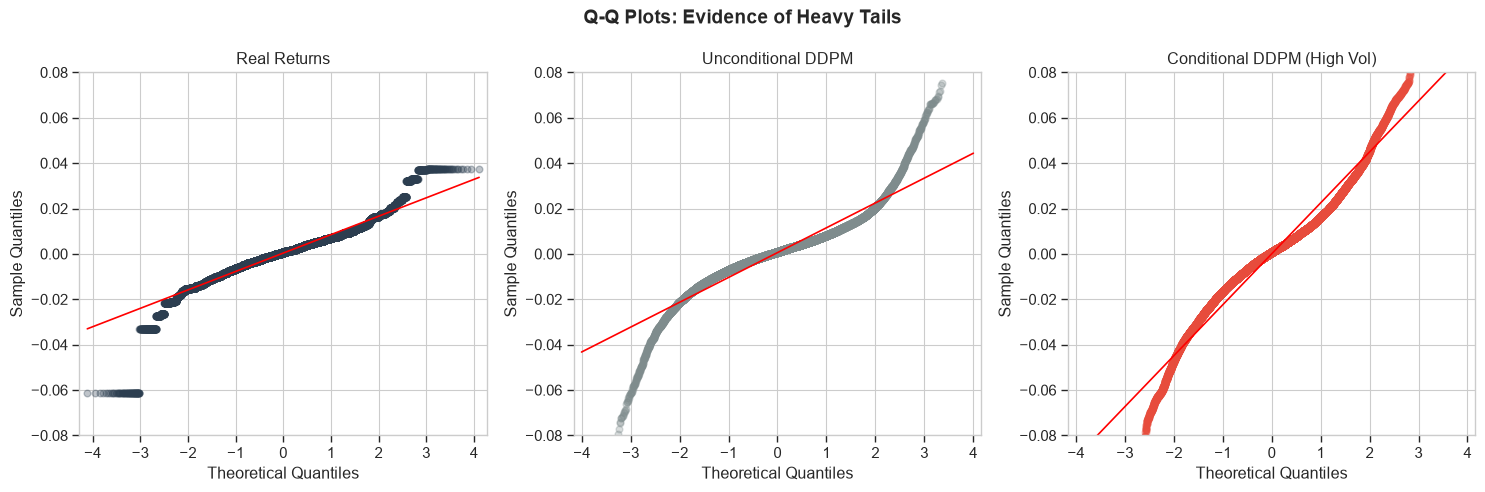

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Q-Q Plots: Evidence of Heavy Tails', fontweight='bold', fontsize=14)

def plot_qq(data, title, ax, color):
    sm.qqplot(data, line='s', ax=ax, markerfacecolor=color, markeredgecolor=color, alpha=0.3)
    ax.set_title(title)
    ax.set_ylim(-0.08, 0.08)

plot_qq(real_flat, 'Real Returns', axes[0], colors['Real'])
plot_qq(uncond_flat, 'Unconditional DDPM', axes[1], colors['Uncond'])
plot_qq(cond_high_flat, 'Conditional DDPM (High Vol)', axes[2], colors['Cond-High'])

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb05_qq_plots.png'), dpi=300)
plt.savefig(os.path.join(FIG_DIR, 'nb05_qq_plots.pdf'))
plt.show()


## Cell 8 & 9 â€” Publication Figure: Autocorrelation & Volatility Clustering

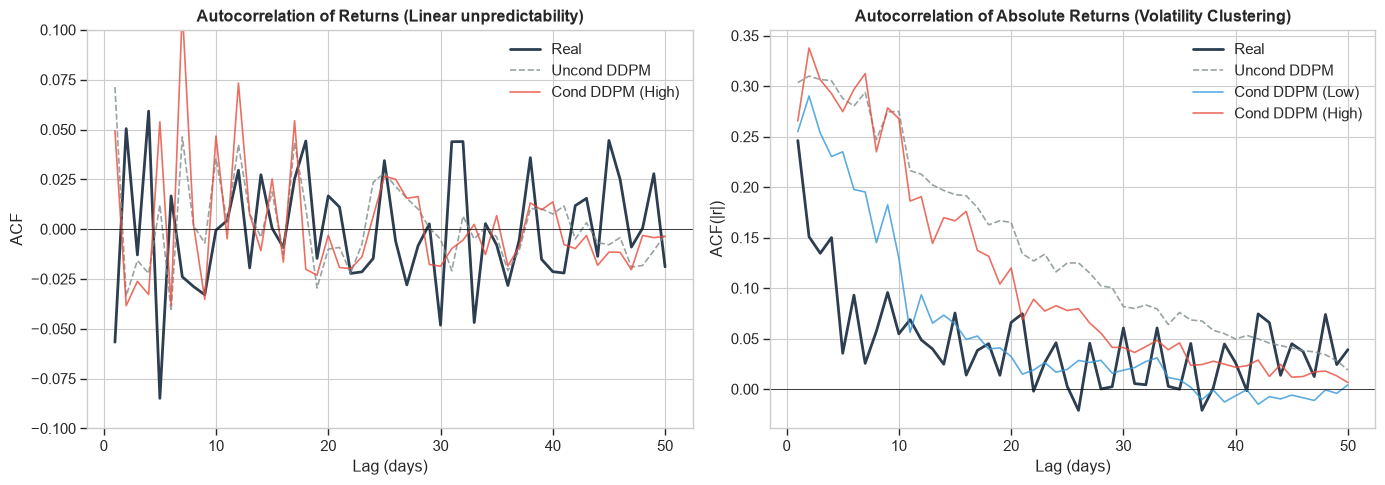

In [7]:
lags = 50
lags_x = np.arange(1, lags + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF of Returns (Should be ~0)
axes[0].plot(lags_x, compute_acf(real_flat, lags), label='Real', color=colors['Real'], lw=2)
axes[0].plot(lags_x, compute_acf(uncond_flat, lags), label='Uncond DDPM', color=colors['Uncond'], alpha=0.8, linestyle='--')
axes[0].plot(lags_x, compute_acf(cond_high_flat, lags), label='Cond DDPM (High)', color=colors['Cond-High'], alpha=0.8)
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Autocorrelation of Returns (Linear unpredictability)', fontweight='bold')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('ACF')
axes[0].set_ylim(-0.1, 0.1)
axes[0].legend()

# ACF of Absolute Returns (Volatility Clustering)
axes[1].plot(lags_x, compute_acf(np.abs(real_flat), lags), label='Real', color=colors['Real'], lw=2)
axes[1].plot(lags_x, compute_acf(np.abs(uncond_flat), lags), label='Uncond DDPM', color=colors['Uncond'], alpha=0.8, linestyle='--')
axes[1].plot(lags_x, compute_acf(np.abs(cond_low_flat), lags), label='Cond DDPM (Low)', color=colors['Cond-Low'], alpha=0.8)
axes[1].plot(lags_x, compute_acf(np.abs(cond_high_flat), lags), label='Cond DDPM (High)', color=colors['Cond-High'], alpha=0.8)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Autocorrelation of Absolute Returns (Volatility Clustering)', fontweight='bold')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('ACF(|r|)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb05_acf_clustering.png'), dpi=300)
plt.savefig(os.path.join(FIG_DIR, 'nb05_acf_clustering.pdf'))
plt.show()


## Cell 10 â€” Publication Figure: Leverage Effect

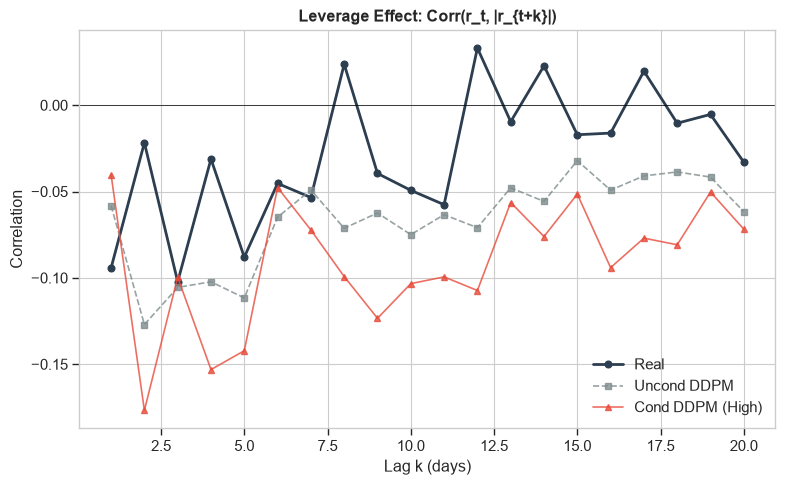

In [8]:
lags = 20
lags_x = np.arange(1, lags + 1)

plt.figure(figsize=(8, 5))
plt.plot(lags_x, compute_leverage(real_flat, lags), 'o-', label='Real', color=colors['Real'], lw=2)
plt.plot(lags_x, compute_leverage(uncond_flat, lags), 's--', label='Uncond DDPM', color=colors['Uncond'], alpha=0.8)
plt.plot(lags_x, compute_leverage(cond_high_flat, lags), '^-', label='Cond DDPM (High)', color=colors['Cond-High'], alpha=0.8)

plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.title('Leverage Effect: Corr(r_t, |r_{t+k}|)', fontweight='bold')
plt.xlabel('Lag k (days)')
plt.ylabel('Correlation')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb05_leverage_effect.png'), dpi=300)
plt.savefig(os.path.join(FIG_DIR, 'nb05_leverage_effect.pdf'))
plt.show()


## Cell 11 â€” Publication Figure: Sample Cumulative Trajectories

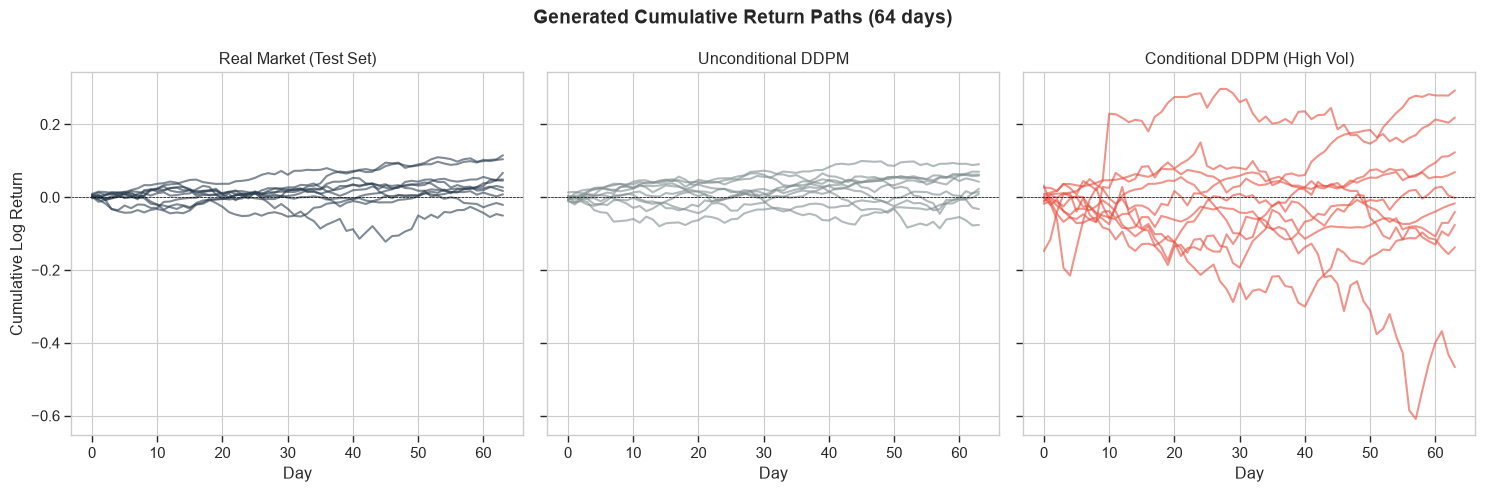

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Generated Cumulative Return Paths (64 days)', fontweight='bold', fontsize=14)

def plot_paths(windows, ax, title, color):
    np.random.seed(10)
    idx = np.random.choice(len(windows), 10, replace=False)
    for i in idx:
        cum_ret = np.cumsum(windows[i])
        ax.plot(cum_ret, color=color, alpha=0.6, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Day')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plot_paths(real_returns, axes[0], 'Real Market (Test Set)', colors['Real'])
plot_paths(uncond_returns, axes[1], 'Unconditional DDPM', colors['Uncond'])
plot_paths(cond_high_returns, axes[2], 'Conditional DDPM (High Vol)', colors['Cond-High'])

axes[0].set_ylabel('Cumulative Log Return')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb05_sample_paths.png'), dpi=300)
plt.savefig(os.path.join(FIG_DIR, 'nb05_sample_paths.pdf'))
plt.show()
